In [1]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()

Saving PakMart_Retail_Sales.csv to PakMart_Retail_Sales.csv


In [4]:
df = pd.read_csv("PakMart_Retail_Sales.csv")

In [5]:
df.head()

,Transaction_ID,Customer_ID,Purchase_Date,Customer_Name,Gender,Age,City,Product_Category,Product_Name,Quantity,Unit_Price,Discount,Total_Amount,Payment_Method
0,TXN000001,CUST0176,2025-10-29,Hassan Ali,Male,33,Islamabad,Gaming,PS Controller,2,18000,0,36000,Cash
1,TXN000002,CUST0176,2025-04-28,Hassan Ali,Male,55,Lahore,Electronics,Tablet,3,70000,0,210000,Cash
2,TXN000003,CUST0061,2025-09-13,Zain Malik,Male,44,Multan,Electronics,Smart Watch,1,25000,15,21250,Cash
3,TXN000004,CUST0257,2025-10-29,Sara Ahmed,Female,20,Multan,Gaming,Gaming Mouse,1,6500,5,6175,JazzCash
4,TXN000005,CUST0281,2025-02-24,Hamza Shah,Male,43,Karachi,Electronics,Smartphone,2,90000,15,153000,Debit Card


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_ID    1215 non-null   object
 1   Customer_ID       1215 non-null   object
 2   Purchase_Date     1215 non-null   object
 3   Customer_Name     1204 non-null   object
 4   Gender            1215 non-null   object
 5   Age               1215 non-null   int64 
 6   City              1205 non-null   object
 7   Product_Category  1215 non-null   object
 8   Product_Name      1215 non-null   object
 9   Quantity          1215 non-null   int64 
 10  Unit_Price        1215 non-null   int64 
 11  Discount          1215 non-null   int64 
 12  Total_Amount      1215 non-null   int64 
 13  Payment_Method    1205 non-null   object
dtypes: int64(5), object(9)
memory usage: 133.0+ KB


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1215, 14)


In [8]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Purchase_Date,0
Customer_Name,11
Gender,0
Age,0
City,10
Product_Category,0
Product_Name,0
Quantity,0


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 15


In [10]:
print(df["City"].unique())

['Islamabad' 'Lahore' 'Multan' 'Karachi' 'Rawalpindi' 'Faisalabad'
 'Peshawar' 'Hyderabad' 'LAHORE' 'Sialkot' 'islamabad' 'karachi' 'Quetta'
 nan]


In [11]:
print(df["Payment_Method"].unique())

['Cash' 'JazzCash' 'Debit Card' 'Credit Card' 'EasyPaisa' nan
 'credit card']


Filling Missing Values

In [12]:
df["Customer_Name"] = df["Customer_Name"].fillna("Unknown")
df["City"] = df["City"].fillna("Unknown")
df["Payment_Method"] = df["Payment_Method"].fillna("Unknown")

In [13]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Purchase_Date,0
Customer_Name,0
Gender,0
Age,0
City,0
Product_Category,0
Product_Name,0
Quantity,0


Removing Duplicate Rows

In [14]:
df = df.drop_duplicates()

In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Standarize City Names

In [16]:
df["City"] = df["City"].replace({
    "karachi": "Karachi",
    "LAHORE": "Lahore",
    "islamabad": "Islamabad"
})

In [17]:
print(df["City"].unique())

['Islamabad' 'Lahore' 'Multan' 'Karachi' 'Rawalpindi' 'Faisalabad'
 'Peshawar' 'Hyderabad' 'Sialkot' 'Quetta' 'Unknown']


Standarize Payment Method

In [18]:
df["Payment_Method"] = df["Payment_Method"].replace({
    "credit card": "Credit Card"
})

In [19]:
print(df["Payment_Method"].unique())

['Cash' 'JazzCash' 'Debit Card' 'Credit Card' 'EasyPaisa' 'Unknown']


In [20]:
df.dtypes

,0
Transaction_ID,object
Customer_ID,object
Purchase_Date,object
Customer_Name,object
Gender,object
Age,int64
City,object
Product_Category,object
Product_Name,object
Quantity,int64


In [21]:
df.to_csv("PakMart_Retail_Sales_Cleaned.csv", index=False)

In [22]:
from google.colab import files
files.download("PakMart_Retail_Sales_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exploratory Data Analysis (EDA)

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar

In [42]:
df = pd.read_csv("PakMart_Retail_Sales_Cleaned.csv")

In [43]:
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

In [44]:
df["Month"] = df["Purchase_Date"].dt.month_name()

month_order = list(calendar.month_name)[1:]

df["Month"] = pd.Categorical(
    df["Month"],
    categories=month_order,
    ordered=True
)

In [25]:
df.head()

,Transaction_ID,Customer_ID,Purchase_Date,Customer_Name,Gender,Age,City,Product_Category,Product_Name,Quantity,Unit_Price,Discount,Total_Amount,Payment_Method
0,TXN000001,CUST0176,2025-10-29,Hassan Ali,Male,33,Islamabad,Gaming,PS Controller,2,18000,0,36000,Cash
1,TXN000002,CUST0176,2025-04-28,Hassan Ali,Male,55,Lahore,Electronics,Tablet,3,70000,0,210000,Cash
2,TXN000003,CUST0061,2025-09-13,Zain Malik,Male,44,Multan,Electronics,Smart Watch,1,25000,15,21250,Cash
3,TXN000004,CUST0257,2025-10-29,Sara Ahmed,Female,20,Multan,Gaming,Gaming Mouse,1,6500,5,6175,JazzCash
4,TXN000005,CUST0281,2025-02-24,Hamza Shah,Male,43,Karachi,Electronics,Smartphone,2,90000,15,153000,Debit Card


In [26]:
df.describe()

,Age,Quantity,Unit_Price,Discount,Total_Amount
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,39.114167,2.061667,39695.000000,6.083333,75362.229167
std,12.214286,1.212059,50908.775221,6.243707,118737.800240
min,18.000000,1.000000,1200.000000,0.000000,960.000000
25%,29.000000,1.000000,6500.000000,0.000000,11400.000000
50%,39.000000,2.000000,18000.000000,5.000000,27100.000000
75%,50.000000,3.000000,70000.000000,10.000000,85500.000000
max,60.000000,5.000000,180000.000000,20.000000,900000.000000


Monthly Sales Trend

In [45]:
monthly_sales = (
    df.groupby("Month", observed=True)["Total_Amount"]
      .sum()
      .reindex(month_order)
)

print(monthly_sales)

Month
January      7566885
February     7307610
March        6958305
April        8528375
May          9639645
June         8225475
July         8901475
August       7963615
September    6723460
October      7203100
November     5430055
December     5986675
Name: Total_Amount, dtype: int64


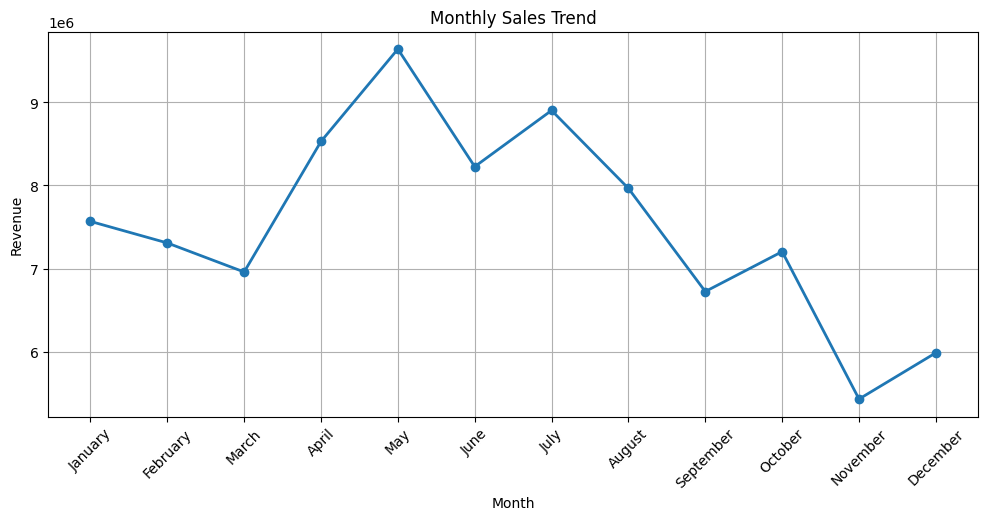

In [46]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o",
         linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Top Selling Products

In [47]:
top_products = (
    df.groupby("Product_Name")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product_Name
Smart Watch        269
Smartphone         209
Laptop             205
Tablet             204
Power Bank         152
Gaming Keyboard    135
Keyboard           132
Mouse              129
Headphones         124
Gaming Mouse       121
Name: Quantity, dtype: int64


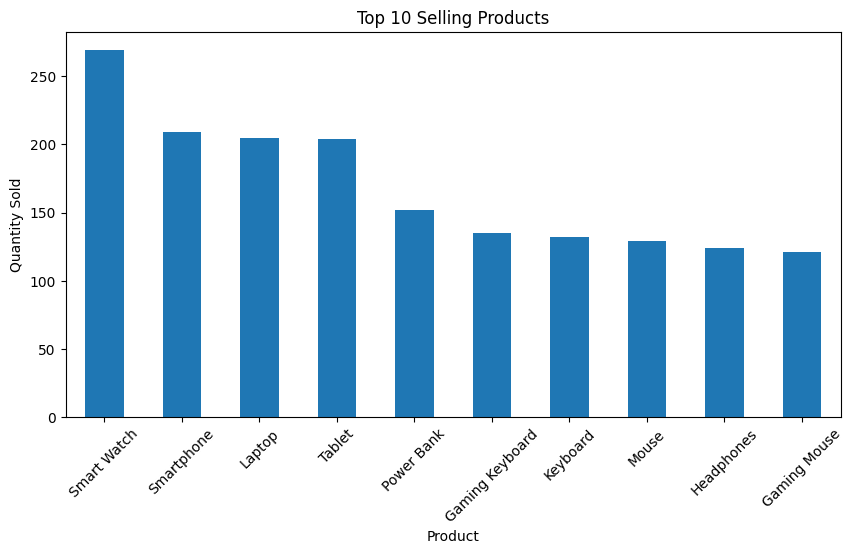

In [48]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")

plt.xlabel("Product")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.show()

Category Performance

In [49]:
category_sales = (
    df.groupby("Product_Category")["Total_Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Product_Category
Electronics        71825000
Home Appliances     7708525
Office              4165550
Gaming              4009700
Accessories         2725900
Name: Total_Amount, dtype: int64


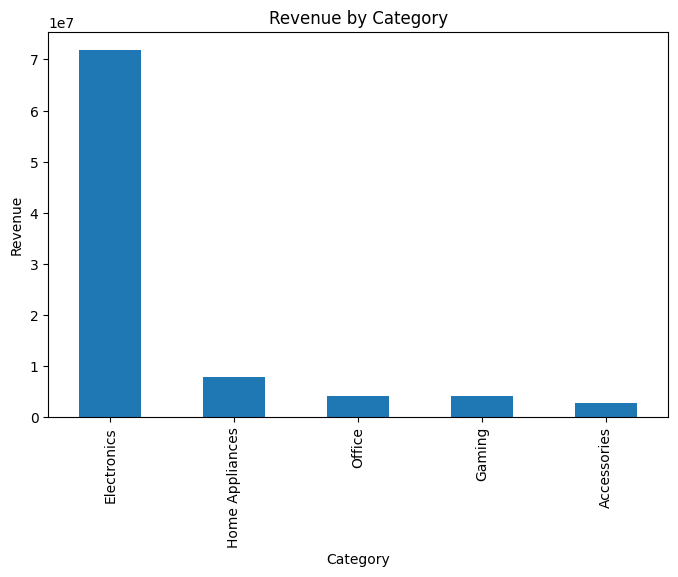

In [50]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.show()

Revenue by City

In [51]:
city_sales = (
    df.groupby("City")["Total_Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(city_sales)

City
Lahore        17711365
Karachi       17595905
Islamabad     16511200
Rawalpindi     9936985
Faisalabad     6945450
Multan         6321335
Hyderabad      5721950
Peshawar       5245025
Sialkot        2608535
Quetta         1112325
Unknown         724600
Name: Total_Amount, dtype: int64


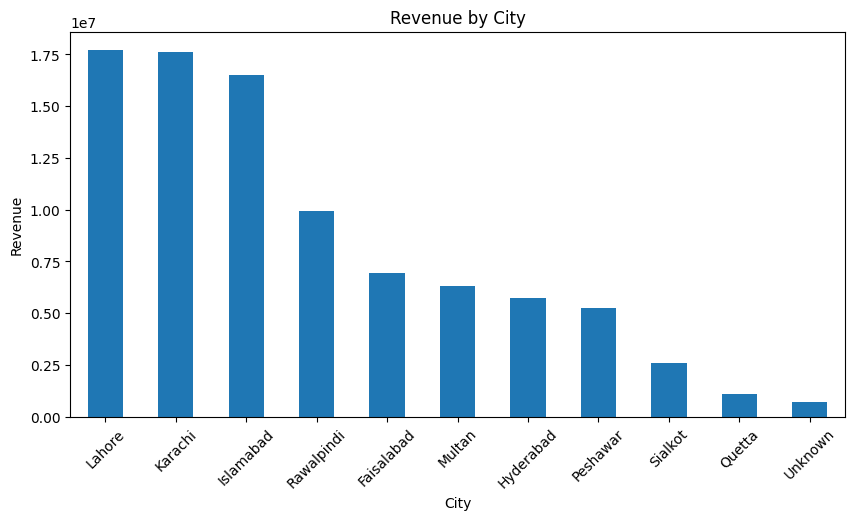

In [52]:
plt.figure(figsize=(10,5))

city_sales.plot(kind="bar")

plt.title("Revenue by City")

plt.xlabel("City")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

Customer Purchasing Pattern

In [53]:
customer_orders = (
    df.groupby("Customer_ID")["Total_Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(customer_orders)

Customer_ID
CUST0022    1314225
CUST0348    1216000
CUST0054    1213150
CUST0188    1096200
CUST0118    1048500
CUST0114    1040870
CUST0399    1026650
CUST0138     980100
CUST0040     971100
CUST0343     970575
Name: Total_Amount, dtype: int64


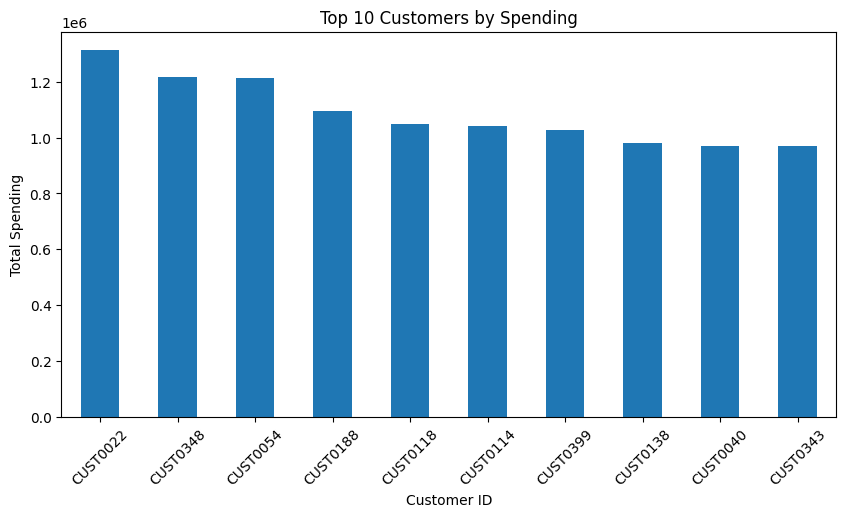

In [54]:
plt.figure(figsize=(10,5))

customer_orders.plot(kind="bar")

plt.title("Top 10 Customers by Spending")

plt.xlabel("Customer ID")

plt.ylabel("Total Spending")

plt.xticks(rotation=45)

plt.show()

Payment Method Distribution

In [55]:
payment = df["Payment_Method"].value_counts()

print(payment)

Payment_Method
Cash           434
Debit Card     292
Credit Card    223
JazzCash       136
EasyPaisa      105
Unknown         10
Name: count, dtype: int64


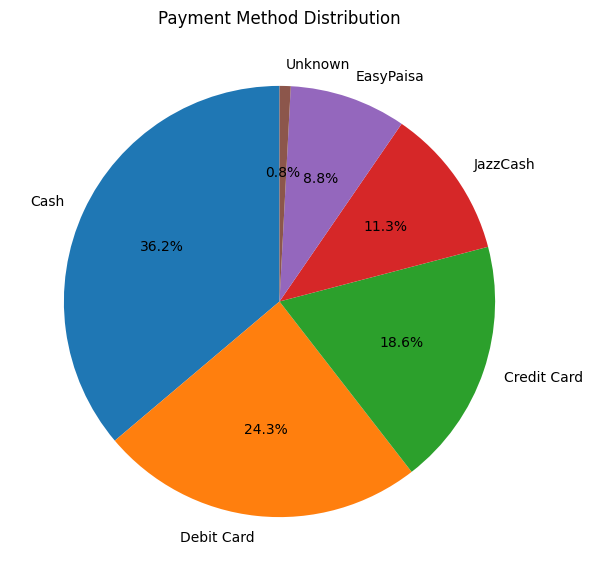

In [56]:
plt.figure(figsize=(7,7))

plt.pie(payment,
        labels=payment.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Payment Method Distribution")

plt.show()

Average Order Value

In [57]:
average_order = df["Total_Amount"].mean()

print("Average Order Value =", round(average_order,2))

Average Order Value = 75362.23


Peak Sales Month

In [58]:
peak_month = monthly_sales.idxmax()

peak_sales = monthly_sales.max()

print("Peak Sales Month :", peak_month)
print("Revenue :", peak_sales)

Peak Sales Month : May
Revenue : 9639645


Revenue Summary

In [59]:
print("Total Revenue :", round(df["Total_Amount"].sum(),2))
print("Total Orders :", len(df))
print("Unique Customers :", df["Customer_ID"].nunique())

Total Revenue : 90434675
Total Orders : 1200
Unique Customers : 418


Business Insights

Insight 1: Monthly Sales Trend

In [60]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

print("Highest Sales Month:", highest_month)
print("Revenue:", highest_sales)

Highest Sales Month: May
Revenue: 9639645


Insight 2: Top Selling Product

In [61]:
top_product = (
    df.groupby("Product_Name")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

print(top_product.head())

Product_Name
Smart Watch    269
Smartphone     209
Laptop         205
Tablet         204
Power Bank     152
Name: Quantity, dtype: int64


Insight 3: Best Performing Category

In [62]:
best_category = (
    df.groupby("Product_Category")["Total_Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(best_category)

Product_Category
Electronics        71825000
Home Appliances     7708525
Office              4165550
Gaming              4009700
Accessories         2725900
Name: Total_Amount, dtype: int64


Insight 4: Highest Revenue City

In [63]:
top_city = (
    df.groupby("City")["Total_Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(top_city)

City
Lahore        17711365
Karachi       17595905
Islamabad     16511200
Rawalpindi     9936985
Faisalabad     6945450
Multan         6321335
Hyderabad      5721950
Peshawar       5245025
Sialkot        2608535
Quetta         1112325
Unknown         724600
Name: Total_Amount, dtype: int64


Insight 5: Payment Method

In [64]:
payment_method = df["Payment_Method"].value_counts()

print(payment_method)

Payment_Method
Cash           434
Debit Card     292
Credit Card    223
JazzCash       136
EasyPaisa      105
Unknown         10
Name: count, dtype: int64


Insight 6: Customer Spending

In [65]:
top_customer = (
    df.groupby("Customer_ID")["Total_Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(top_customer.head())

Customer_ID
CUST0022    1314225
CUST0348    1216000
CUST0054    1213150
CUST0188    1096200
CUST0118    1048500
Name: Total_Amount, dtype: int64


Insight 7: Average Order Value

In [66]:
avg = df["Total_Amount"].mean()

print(avg)

75362.22916666667
